# Benchmark Multimodal (Vision)

Este notebook compara **Kimi**, **Claude Opus**, **GPT-4o** e **Gemini** em tarefas que envolvem análise de imagens.

**Objetivo:** medir precisão, tempo, custo e capacidade de interpretação visual.

**Métricas:**
- Tokens de entrada e saída
- Tempo de resposta
- Custo estimado
- Avaliação de qualidade da descrição/OCR
- Capacidade de raciocínio visual

## 1. Instalação das dependências

In [ ]:
# !pip install openai anthropic google-generativeai python-dotenv pandas matplotlib pillow

## 2. Configuração do ambiente

In [1]:
import os
import time
import base64
import io
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
from dotenv import load_dotenv

import openai
import anthropic
import google.generativeai as genai

load_dotenv()

KIMI_API_KEY = os.getenv("KIMI_API_KEY")
ANTHROPIC_API_KEY = os.getenv("ANTHROPIC_API_KEY")
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")

kimi_client = openai.OpenAI(api_key=KIMI_API_KEY, base_url="https://api.moonshot.ai/v1")
anthropic_client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)
openai_client = openai.OpenAI(api_key=OPENAI_API_KEY)
genai.configure(api_key=GOOGLE_API_KEY)

/var/folders/9y/vfydzyxd3xj94k6mxydczgvc0000gn/T/ipykernel_73453/3972383922.py:12: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


## 3. Tabela de preços

In [2]:
# Preços por 1M tokens (USD) — verificados em 2026-08-03.
# As chaves precisam bater com o campo "provider" retornado por cada call_*().
PRICES = {
    "kimi":        {"input":  3.00, "output": 15.00},  # kimi-k3 (Moonshot)
    "claude-opus": {"input":  5.00, "output": 25.00},  # claude-opus-5 (Anthropic)
    "gpt-5.6-terra": {"input":  2.00, "output": 12.00},  # gpt-5.6-terra (OpenAI)
    "gemini":      {"input":  1.50, "output":  7.50},  # gemini-3.6-flash (Google)
}


## 4. Geração de imagens de teste

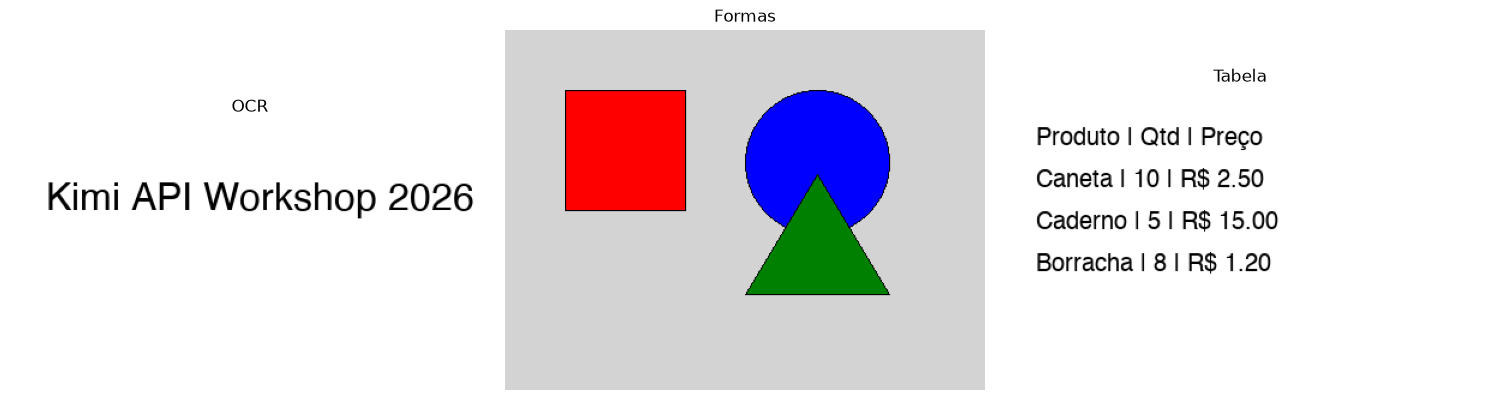

In [3]:
def create_test_image_1():
    """Imagem com texto simples para OCR."""
    img = Image.new("RGB", (400, 150), color="white")
    draw = ImageDraw.Draw(img)
    try:
        font = ImageFont.truetype("/System/Library/Fonts/Helvetica.ttc", 32)
    except:
        font = ImageFont.load_default()
    draw.text((30, 50), "Kimi API Workshop 2026", fill="black", font=font)
    return img

def create_test_image_2():
    """Imagem com formas geométricas e cores."""
    img = Image.new("RGB", (400, 300), color="lightgray")
    draw = ImageDraw.Draw(img)
    draw.rectangle([50, 50, 150, 150], fill="red", outline="black")
    draw.ellipse([200, 50, 320, 170], fill="blue", outline="black")
    draw.polygon([(200, 220), (260, 120), (320, 220)], fill="green", outline="black")
    return img

def create_test_image_3():
    """Imagem com dados tabulares simples."""
    img = Image.new("RGB", (400, 200), color="white")
    draw = ImageDraw.Draw(img)
    try:
        font = ImageFont.truetype("/System/Library/Fonts/Helvetica.ttc", 20)
    except:
        font = ImageFont.load_default()
    data = ["Produto | Qtd | Preço", "Caneta | 10 | R$ 2.50", "Caderno | 5 | R$ 15.00", "Borracha | 8 | R$ 1.20"]
    y = 30
    for line in data:
        draw.text((30, y), line, fill="black", font=font)
        y += 35
    return img

img_ocr = create_test_image_1()
img_shapes = create_test_image_2()
img_table = create_test_image_3()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(img_ocr); axes[0].set_title("OCR"); axes[0].axis("off")
axes[1].imshow(img_shapes); axes[1].set_title("Formas"); axes[1].axis("off")
axes[2].imshow(img_table); axes[2].set_title("Tabela"); axes[2].axis("off")
plt.tight_layout()
plt.show()

In [4]:
def image_to_base64(img):
    buffer = io.BytesIO()
    img.save(buffer, format="PNG")
    return base64.b64encode(buffer.getvalue()).decode("utf-8")

b64_ocr = image_to_base64(img_ocr)
b64_shapes = image_to_base64(img_shapes)
b64_table = image_to_base64(img_table)

## 5. Funções padronizadas de chamada (com imagem)

In [5]:
def call_kimi_vision(user_prompt, b64_image, model="kimi-k3"):
    start = time.time()
    response = kimi_client.chat.completions.create(
        model=model,
        messages=[{
            "role": "user",
            "content": [
                {"type": "text", "text": user_prompt},
                {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{b64_image}"}}
            ]
        }],
        temperature=1.0
    )
    elapsed = time.time() - start
    return {
        "provider": "kimi",
        "model": model,
        "response": response.choices[0].message.content,
        "input_tokens": response.usage.prompt_tokens,
        "output_tokens": response.usage.completion_tokens,
        "total_tokens": response.usage.total_tokens,
        "time_seconds": elapsed
    }

def call_claude_vision(user_prompt, b64_image, model="claude-opus-5"):
    start = time.time()
    # O claude-opus-5 não aceita temperature e vem com thinking ligado por padrão,
    # que consome parte do max_tokens — daí o limite mais folgado.
    response = anthropic_client.messages.create(
        model=model,
        max_tokens=16000,
        messages=[{
            "role": "user",
            "content": [
                {"type": "text", "text": user_prompt},
                {"type": "image", "source": {"type": "base64", "media_type": "image/png", "data": b64_image}}
            ]
        }]
    )
    elapsed = time.time() - start
    # Com thinking ligado, content[0] é um bloco 'thinking'; o texto vem depois.
    text = next(b.text for b in response.content if b.type == "text")
    return {
        "provider": "claude-opus",
        "model": model,
        "response": text,
        "input_tokens": response.usage.input_tokens,
        "output_tokens": response.usage.output_tokens,
        "total_tokens": response.usage.input_tokens + response.usage.output_tokens,
        "time_seconds": elapsed
    }

def call_openai_vision(user_prompt, b64_image, model="gpt-5.6-terra"):
    start = time.time()
    # temperature é omitido de propósito: o gpt-5.5 rejeitava qualquer valor != 1
    # (400 unsupported_value) e o padrão do provider funciona em qualquer modelo.
    response = openai_client.chat.completions.create(
        model=model,
        messages=[{
            "role": "user",
            "content": [
                {"type": "text", "text": user_prompt},
                {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{b64_image}"}}
            ]
        }]
    )
    elapsed = time.time() - start
    return {
        "provider": "gpt-5.6-terra",
        "model": model,
        "response": response.choices[0].message.content,
        "input_tokens": response.usage.prompt_tokens,
        "output_tokens": response.usage.completion_tokens,
        "total_tokens": response.usage.total_tokens,
        "time_seconds": elapsed
    }

def call_gemini_vision(user_prompt, b64_image, model="gemini-3.6-flash"):
    start = time.time()
    gemini_model = genai.GenerativeModel(model)
    image_bytes = base64.b64decode(b64_image)
    image = Image.open(io.BytesIO(image_bytes))
    response = gemini_model.generate_content(
        [user_prompt, image],
        generation_config={"temperature": 0.3}
    )
    elapsed = time.time() - start
    usage = response.usage_metadata
    # O preço de output do Gemini inclui os tokens de raciocínio, que NÃO entram
    # em candidates_token_count e não são expostos em campo próprio neste SDK.
    # (total - prompt) captura raciocínio + resposta, que é o que é cobrado.
    output_tokens = usage.total_token_count - usage.prompt_token_count
    return {
        "provider": "gemini",
        "model": model,
        "response": response.text,
        "input_tokens": usage.prompt_token_count,
        "output_tokens": output_tokens,
        "total_tokens": usage.total_token_count,
        "time_seconds": elapsed
    }


## 6. Funções auxiliares

In [6]:
def calculate_cost(provider, input_tokens, output_tokens):
    prices = PRICES.get(provider, {})
    input_cost = (input_tokens / 1_000_000) * prices.get("input", 0)
    output_cost = (output_tokens / 1_000_000) * prices.get("output", 0)
    return round(input_cost + output_cost, 6)

# Nome do provider por função de chamada — usado quando a call falha, para que a
# linha de erro use a mesma chave de PRICES e não vire uma categoria extra nos gráficos.
CALLER_PROVIDERS = {
    "call_kimi_vision": "kimi",
    "call_claude_vision": "claude-opus",
    "call_openai_vision": "gpt-5.6-terra",
    "call_gemini_vision": "gemini",
}

# Colunas métricas — o texto da resposta fica fora daqui.
METRIC_COLUMNS = [
    "task", "provider", "model",
    "input_tokens", "output_tokens", "total_tokens",
    "time_seconds", "cost_usd",
]

def metrics(df):
    """Versão só com métricas, para exibir a tabela sem o texto das respostas."""
    return df[METRIC_COLUMNS]

def run_vision_benchmark(user_prompt, b64_image, task_name="tarefa"):
    results = []
    callers = [call_kimi_vision, call_claude_vision, call_openai_vision, call_gemini_vision]
    for caller in callers:
        try:
            result = caller(user_prompt, b64_image)
            result["cost_usd"] = calculate_cost(
                result["provider"],
                result["input_tokens"],
                result["output_tokens"]
            )
            result["task"] = task_name
            results.append(result)
        except Exception as e:
            results.append({
                "provider": CALLER_PROVIDERS.get(caller.__name__, caller.__name__),
                "model": "error",
                "response": f"[ERRO] {type(e).__name__}: {e}",
                "input_tokens": 0,
                "output_tokens": 0,
                "total_tokens": 0,
                "time_seconds": 0,
                "cost_usd": 0,
                "task": task_name
            })
    df = pd.DataFrame(results)
    # Mantém "response": as células seguintes exibem o texto de cada modelo.
    return df[METRIC_COLUMNS + ["response"]]


## 7. Benchmark 1 — OCR e transcrição de texto

In [7]:
prompt_ocr = "Transcreva TODO o texto presente nesta imagem. Responda apenas com o texto."
df_ocr = run_vision_benchmark(prompt_ocr, b64_ocr, task_name="ocr_texto")
metrics(df_ocr)


,task,provider,model,input_tokens,output_tokens,total_tokens,time_seconds,cost_usd
0,ocr_texto,kimi,kimi-k3,204,57,261,7.299061,0.001467
1,ocr_texto,claude-opus,claude-opus-5,130,36,166,3.530771,0.001550
2,ocr_texto,gpt-5.6-terra,gpt-5.6-terra,103,10,113,2.126654,0.000326
3,ocr_texto,gemini,gemini-3.6-flash,1098,52,1150,2.176647,0.002037


In [8]:
for _, row in df_ocr.iterrows():
    print(f"\n=== {row['provider'].upper()} ===")
    print(row["response"])



=== KIMI ===
Kimi API Workshop 2026

=== CLAUDE-OPUS ===
Kimi API Workshop 2026

=== GPT-5.6-TERRA ===
Kimi API Workshop 2026

=== GEMINI ===
Kimi API Workshop 2026


## 8. Benchmark 2 — Descrição e contagem de objetos

In [9]:
prompt_shapes = """
Descreva a imagem e responda:
1. Quantas formas geométricas há?
2. Quais são suas cores?
3. Qual forma está mais à direita?
"""

df_shapes = run_vision_benchmark(prompt_shapes, b64_shapes, task_name="formas_cores")
metrics(df_shapes)


,task,provider,model,input_tokens,output_tokens,total_tokens,time_seconds,cost_usd
0,formas_cores,kimi,kimi-k3,300,589,889,23.304581,0.009735
1,formas_cores,claude-opus,claude-opus-5,229,635,864,9.914643,0.017020
2,formas_cores,gpt-5.6-terra,gpt-5.6-terra,200,83,283,1.804813,0.001396
3,formas_cores,gemini,gemini-3.6-flash,1102,1558,2660,37.427876,0.013338


In [10]:
for _, row in df_shapes.iterrows():
    text = str(row["response"])
    print(f"\n=== {row['provider'].upper()} ===")
    print(text[:800] + ("..." if len(text) > 800 else ""))



=== KIMI ===
# Descrição da Imagem

A imagem mostra um fundo cinza claro com três formas geométricas coloridas: um quadrado à esquerda e, à direita, um círculo sobreposto parcialmente por um triângulo.

## Respostas

**1. Quantas formas geométricas há?**
Há **3 formas geométricas**: um quadrado, um círculo e um triângulo.

**2. Quais são suas cores?**
- Quadrado: **vermelho**
- Círculo: **azul**
- Triângulo: **verde**

**3. Qual forma está mais à direita?**
O **triângulo verde** está mais à direita, pois sua base se estende ligeiramente além da borda direita do círculo azul (ambos estão no lado direito da imagem, sobrepostos).

=== CLAUDE-OPUS ===
## Descrição da imagem

Sobre um fundo cinza-claro, aparecem três figuras geométricas:

- À **esquerda**, um **quadrado vermelho** com contorno escuro, posicionado na parte superior/média da imagem.
- À **direita**, um **círculo azul** grande.
- **Sobreposto** à metade inferior desse círculo, um **triângulo verde** apontando para cima, cuja 

## 9. Benchmark 3 — Extração estruturada de tabela

In [11]:
prompt_table = """
Extraia os dados da tabela desta imagem e retorne como um objeto JSON no formato:
{
  "itens": [
    {"produto": "...", "quantidade": ..., "preco": "..."}
  ]
}
Responda apenas com o JSON.
"""

df_table = run_vision_benchmark(prompt_table, b64_table, task_name="extracao_tabela")
metrics(df_table)


,task,provider,model,input_tokens,output_tokens,total_tokens,time_seconds,cost_usd
0,extracao_tabela,kimi,kimi-k3,272,197,469,8.911934,0.003771
1,extracao_tabela,claude-opus,claude-opus-5,217,124,341,3.470737,0.004185
2,extracao_tabela,gpt-5.6-terra,gpt-5.6-terra,170,70,240,2.076791,0.001180
3,extracao_tabela,gemini,gemini-3.6-flash,1141,762,1903,4.556334,0.007426


In [12]:
for _, row in df_table.iterrows():
    print(f"\n=== {row['provider'].upper()} ===")
    print(row["response"])


=== KIMI ===
{
  "itens": [
    {"produto": "Caneta", "quantidade": 10, "preco": "R$ 2.50"},
    {"produto": "Caderno", "quantidade": 5, "preco": "R$ 15.00"},
    {"produto": "Borracha", "quantidade": 8, "preco": "R$ 1.20"}
  ]
}

=== CLAUDE-OPUS ===
{
  "itens": [
    {"produto": "Caneta", "quantidade": 10, "preco": "R$ 2.50"},
    {"produto": "Caderno", "quantidade": 5, "preco": "R$ 15.00"},
    {"produto": "Borracha", "quantidade": 8, "preco": "R$ 1.20"}
  ]
}

=== GPT-5.6-TERRA ===
{"itens":[{"produto":"Caneta","quantidade":10,"preco":"R$ 2.50"},{"produto":"Caderno","quantidade":5,"preco":"R$ 15.00"},{"produto":"Borracha","quantidade":8,"preco":"R$ 1.20"}]}

=== GEMINI ===
```json
{
  "itens": [
    {
      "produto": "Caneta",
      "quantidade": 10,
      "preco": "R$ 2.50"
    },
    {
      "produto": "Caderno",
      "quantidade": 5,
      "preco": "R$ 15.00"
    },
    {
      "produto": "Borracha",
      "quantidade": 8,
      "preco": "R$ 1.20"
    }
  ]
}
```


## 10. Consolidação dos resultados

In [13]:
df_all = pd.concat([df_ocr, df_shapes, df_table], ignore_index=True)
metrics(df_all)


,task,provider,model,input_tokens,output_tokens,total_tokens,time_seconds,cost_usd
0,ocr_texto,kimi,kimi-k3,204,57,261,7.299061,0.001467
1,ocr_texto,claude-opus,claude-opus-5,130,36,166,3.530771,0.001550
2,ocr_texto,gpt-5.6-terra,gpt-5.6-terra,103,10,113,2.126654,0.000326
3,ocr_texto,gemini,gemini-3.6-flash,1098,52,1150,2.176647,0.002037
4,formas_cores,kimi,kimi-k3,300,589,889,23.304581,0.009735
5,formas_cores,claude-opus,claude-opus-5,229,635,864,9.914643,0.017020
6,formas_cores,gpt-5.6-terra,gpt-5.6-terra,200,83,283,1.804813,0.001396
7,formas_cores,gemini,gemini-3.6-flash,1102,1558,2660,37.427876,0.013338
8,extracao_tabela,kimi,kimi-k3,272,197,469,8.911934,0.003771
9,extracao_tabela,claude-opus,claude-opus-5,217,124,341,3.470737,0.004185


## 11. Visualização comparativa

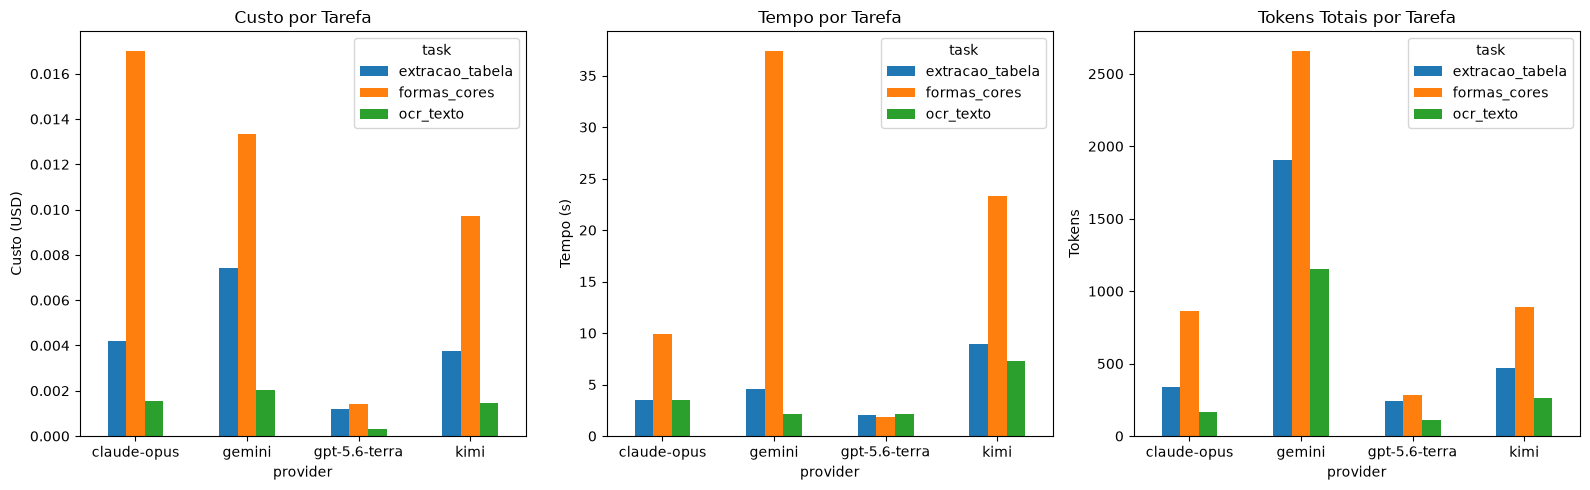

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

cost_pivot = df_all.pivot(index="provider", columns="task", values="cost_usd")
cost_pivot.plot.bar(ax=axes[0], title="Custo por Tarefa", rot=0)
axes[0].set_ylabel("Custo (USD)")

time_pivot = df_all.pivot(index="provider", columns="task", values="time_seconds")
time_pivot.plot.bar(ax=axes[1], title="Tempo por Tarefa", rot=0)
axes[1].set_ylabel("Tempo (s)")

token_pivot = df_all.pivot(index="provider", columns="task", values="total_tokens")
token_pivot.plot.bar(ax=axes[2], title="Tokens Totais por Tarefa", rot=0)
axes[2].set_ylabel("Tokens")

plt.tight_layout()
plt.show()

## 12. Avaliação manual de qualidade

In [15]:
# Atribua notas de 1 a 5 para cada provider em cada tarefa
quality_scores = {
    ("kimi", "ocr_texto"): 4,
    ("claude-opus", "ocr_texto"): 5,
    ("gpt-5.6-terra", "ocr_texto"): 5,
    ("gemini", "ocr_texto"): 4,
    ("kimi", "formas_cores"): 4,
    ("claude-opus", "formas_cores"): 5,
    ("gpt-5.6-terra", "formas_cores"): 5,
    ("gemini", "formas_cores"): 4,
    ("kimi", "extracao_tabela"): 4,
    ("claude-opus", "extracao_tabela"): 5,
    ("gpt-5.6-terra", "extracao_tabela"): 5,
    ("gemini", "extracao_tabela"): 4,
}

df_all["quality_score"] = df_all.apply(
    lambda row: quality_scores.get((row["provider"], row["task"]), 3), axis=1
)

df_all["efficiency"] = df_all.apply(
    lambda row: round(row["quality_score"] / max(row["cost_usd"], 0.000001), 2), axis=1
)

df_all[["task", "provider", "cost_usd", "quality_score", "efficiency"]]

,task,provider,cost_usd,quality_score,efficiency
0,ocr_texto,kimi,0.001467,4,2726.65
1,ocr_texto,claude-opus,0.001550,5,3225.81
2,ocr_texto,gpt-5.6-terra,0.000326,5,15337.42
3,ocr_texto,gemini,0.002037,4,1963.67
4,formas_cores,kimi,0.009735,4,410.89
5,formas_cores,claude-opus,0.017020,5,293.77
6,formas_cores,gpt-5.6-terra,0.001396,5,3581.66
7,formas_cores,gemini,0.013338,4,299.90
8,extracao_tabela,kimi,0.003771,4,1060.73
9,extracao_tabela,claude-opus,0.004185,5,1194.74


## 13. Exportação

In [16]:
# Métricas (planilha enxuta) + respostas completas em arquivo separado
df_all[METRIC_COLUMNS + ["quality_score", "efficiency"]].to_csv(
    "benchmark_multimodal_resultados.csv", index=False
)
df_all.to_csv("benchmark_multimodal_respostas.csv", index=False)
print("Resultados salvos em benchmark_multimodal_resultados.csv")
print("Respostas completas salvas em benchmark_multimodal_respostas.csv")


Resultados salvos em benchmark_multimodal_resultados.csv
Respostas completas salvas em benchmark_multimodal_respostas.csv


## 14. Perguntas para análise

1. Qual modelo teve o OCR mais preciso?
2. Quem melhor identificou as formas e cores?
3. Quem extraiu a tabela no formato JSON mais próximo do esperado?
4. Considerando custo e qualidade, qual modelo teve melhor custo-benefício?